In [1]:
pip uninstall pmdarima

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cellule 1: Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Bibliothèques statistiques
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Auto-ARIMA
from pmdarima import auto_arima

# Métriques
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Style des graphiques
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Configuration affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

In [3]:
df = pd.read_excel("../data/propre/commandes_propres.xlsx")

print(df.shape)

display(df.head())

(34150, 13)


,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE
0,2020-01-13,A0001,C1234,CC2616,5000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
1,2020-01-13,A0002,C1234,CC2616,4000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
2,2020-01-13,A0001,C1249,CC2650,1000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
3,2020-01-13,A0002,C1249,CC2650,16000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
4,2020-01-13,A0001,C1233,CC2614,5000,PROD-BLANC,Expédition vente,AYODELE BUSINESS,STATION OUIDAH,CODO,Fonctionnelle,ST0016,STATION


In [5]:
# CONVERSION DES DATES

df["Date comptabilisation"] = pd.to_datetime(
    df["Date comptabilisation"]
)

print(df["Date comptabilisation"].dtype)

datetime64[ns]


In [7]:
# TRI CHRONOLOGIQUE
# Les variables historiques dépendent : de l’ordre temporel et des commandes précédentes.

df = df.sort_values(
    ["Code Station", "Date comptabilisation"]
)

display(df.head())

,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE
13322,2022-09-27,A0001,C0083,CC6471,20000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,Fonctionnelle,ST0001,STATION
13323,2022-09-27,A0002,C0083,CC6471,15000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,Fonctionnelle,ST0001,STATION
13637,2022-10-17,A0001,C0083,CC6471,8000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,Fonctionnelle,ST0001,STATION
13648,2022-10-17,A0002,C0083,CC6471,10000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,Fonctionnelle,ST0001,STATION
13727,2022-10-20,A0002,C0083,CC6471,8000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,Fonctionnelle,ST0001,STATION


In [9]:
# AGREGER LES COMMANDES JOURNALIERES
# =========================================================

df_daily = (
    df.groupby(
        [
            "Date comptabilisation",
            "Code Station",
            "N° article"
        ]
    )
    .agg({
        "Quantité facturée": "sum"
    })
    .reset_index()
    .copy()
)

In [11]:
all_dates = pd.date_range(
    start=df_daily["Date comptabilisation"].min(),
    end=df_daily["Date comptabilisation"].max(),
    freq="D"
)

In [13]:
df_daily = df_daily.sort_values(
    [
        "Code Station",
        "N° article",
        "Date comptabilisation"
    ]
).copy()

In [15]:
display(df_daily.head(20))

,Date comptabilisation,Code Station,N° article,Quantité facturée
10703,2022-09-27,ST0001,A0001,20000
10959,2022-10-17,ST0001,A0001,8000
11042,2022-10-24,ST0001,A0001,6000
11079,2022-10-25,ST0001,A0001,10000
11143,2022-11-03,ST0001,A0001,15000
11228,2022-11-08,ST0001,A0001,12000
11283,2022-11-11,ST0001,A0001,22000
12009,2023-01-05,ST0001,A0001,10000
12073,2023-01-12,ST0001,A0001,12000
12110,2023-01-16,ST0001,A0001,10000


=== ANALYSE DE ST0001 - A0001 ===
Nombre de commandes: 237
Période: 2022-09-27 à 2025-12-29

Statistiques des quantités (litres):
count      237.000000
mean     13240.506329
std       6492.267610
min       1000.000000
25%      10000.000000
50%      14000.000000
75%      17000.000000
max      40000.000000
Name: Quantité facturée, dtype: float64

Statistiques des délais (jours):
count    236.000000
mean       5.038136
std        5.337406
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       55.000000
Name: Délai_jours, dtype: float64


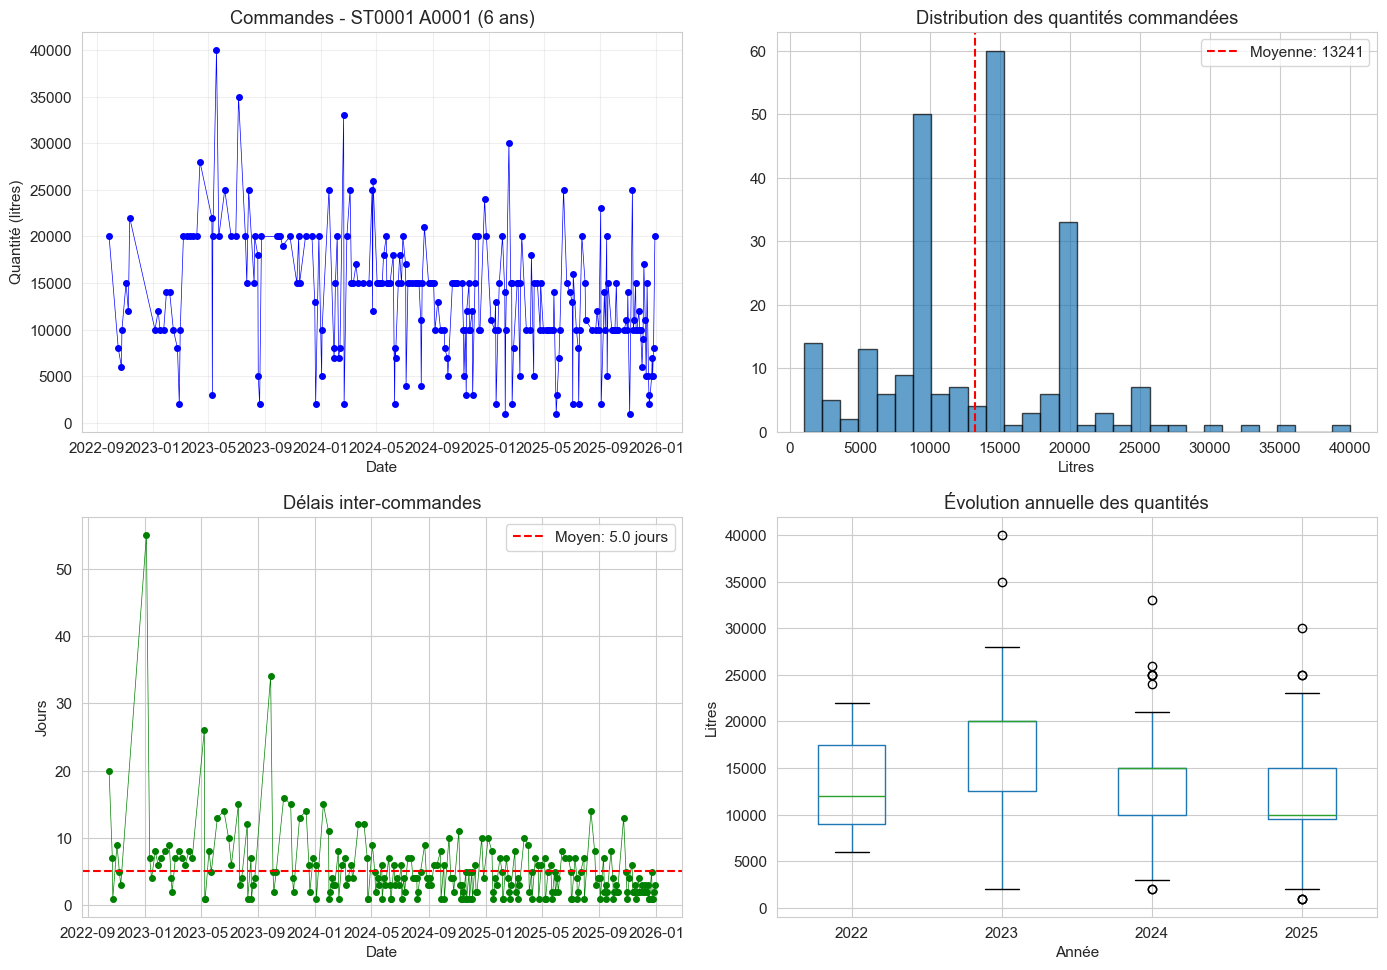

In [17]:
# Cellule 3: Sélection et analyse d'une station représentative
station_test = 'ST0001'
produit_test = 'A0001'

# Filtrer les données
df_test = df_daily[(df_daily['Code Station'] == station_test) & 
             (df_daily['N° article'] == produit_test)].copy()
df_test = df_test.sort_values('Date comptabilisation')

# Statistiques descriptives
print(f"=== ANALYSE DE {station_test} - {produit_test} ===")
print(f"Nombre de commandes: {len(df_test)}")
print(f"Période: {df_test['Date comptabilisation'].min().date()} à {df_test['Date comptabilisation'].max().date()}")
print(f"\nStatistiques des quantités (litres):")
print(df_test['Quantité facturée'].describe())

# Calcul des délais
df_test['Délai_jours'] = df_test['Date comptabilisation'].diff().dt.days
print(f"\nStatistiques des délais (jours):")
print(df_test['Délai_jours'].describe())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Évolution temporelle
axes[0,0].plot(df_test['Date comptabilisation'], df_test['Quantité facturée'], 'bo-', markersize=4, linewidth=0.5)
axes[0,0].set_title(f'Commandes - {station_test} {produit_test} (6 ans)')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Quantité (litres)')
axes[0,0].grid(True, alpha=0.3)

# Distribution des quantités
axes[0,1].hist(df_test['Quantité facturée'], bins=30, edgecolor='black', alpha=0.7)
axes[0,1].axvline(df_test['Quantité facturée'].mean(), color='r', linestyle='--', label=f'Moyenne: {df_test["Quantité facturée"].mean():.0f}')
axes[0,1].set_title('Distribution des quantités commandées')
axes[0,1].set_xlabel('Litres')
axes[0,1].legend()

# Délais entre commandes
axes[1,0].plot(df_test['Date comptabilisation'][1:], df_test['Délai_jours'][1:], 'go-', markersize=4, linewidth=0.5)
axes[1,0].axhline(df_test['Délai_jours'].mean(), color='r', linestyle='--', label=f'Moyen: {df_test["Délai_jours"].mean():.1f} jours')
axes[1,0].set_title('Délais inter-commandes')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Jours')
axes[1,0].legend()

# Boxplot par année
df_test['Année'] = df_test['Date comptabilisation'].dt.year
df_test.boxplot(column='Quantité facturée', by='Année', ax=axes[1,1])
axes[1,1].set_title('Évolution annuelle des quantités')
axes[1,1].set_xlabel('Année')
axes[1,1].set_ylabel('Litres')

plt.suptitle('')
plt.tight_layout()
plt.show()

=== DÉCOMPOSITION ADDITIVE (PÉRIODE 12 MOIS) ===
Nombre de mois: 40
Valeur totale: 3,138,000 litres


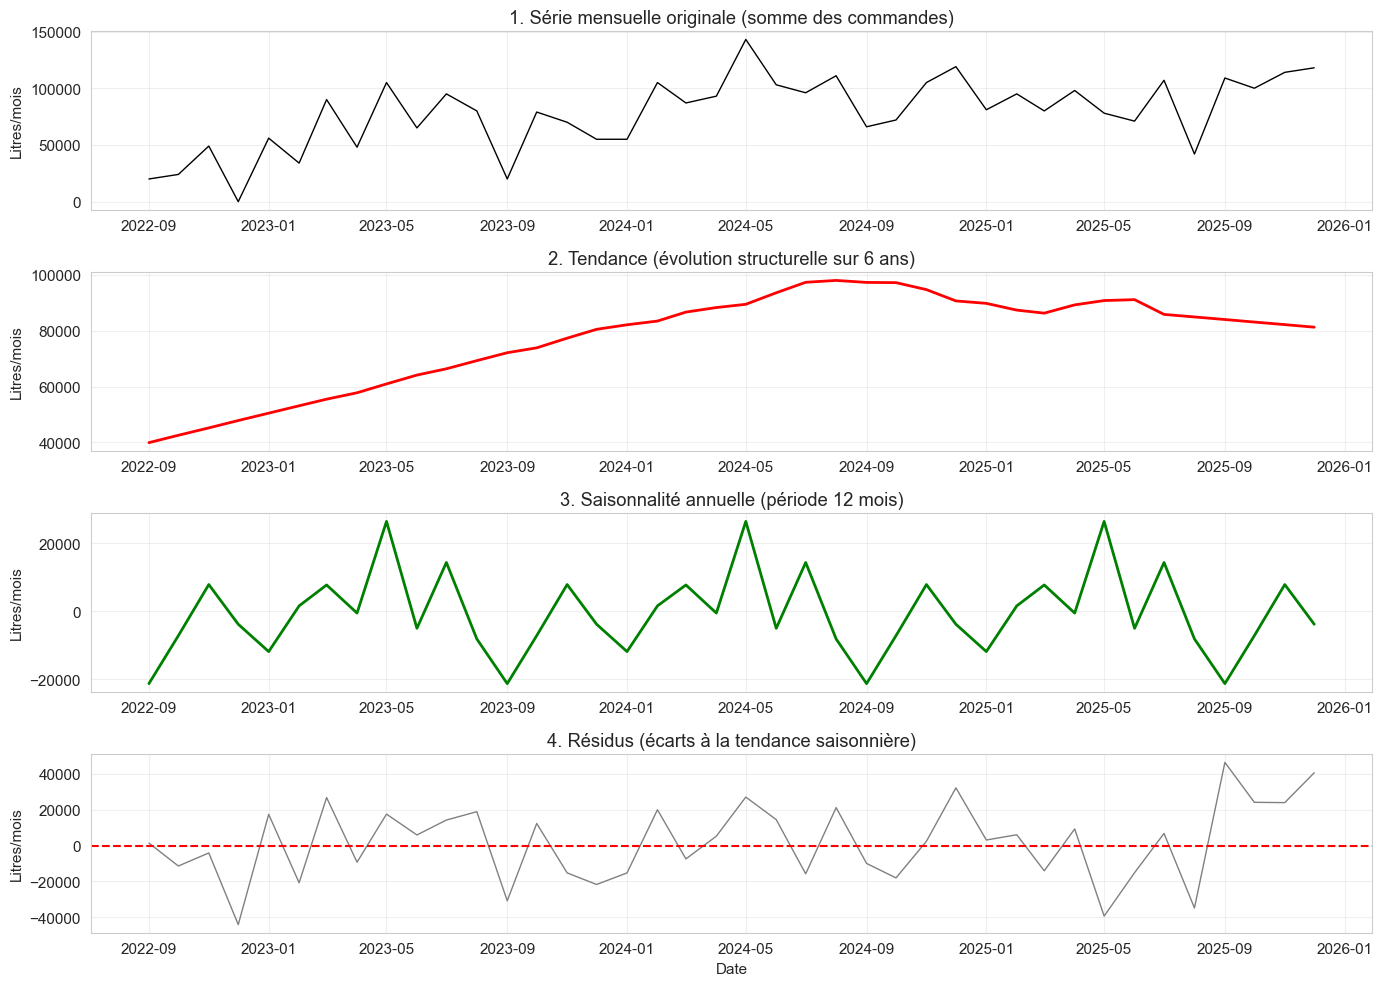


=== STATISTIQUES DES COMPOSANTES ===
Tendance: début = 39942 L/mois, fin = 81271 L/mois
Variation tendance: 103.5%

Saisonnalité mensuelle moyenne:
  Mois  1: -11905 L/mois
  Mois  2: +1577 L/mois
  Mois  3: +7747 L/mois
  Mois  4: -545 L/mois
  Mois  5: +26497 L/mois
  Mois  6: -5045 L/mois
  Mois  7: +14384 L/mois
  Mois  8: -8173 L/mois
  Mois  9: -21360 L/mois
  Mois 10: -7208 L/mois
  Mois 11: +7872 L/mois
  Mois 12: -3841 L/mois

Test de normalité (Jarque-Bera): p-value = 0.710


In [19]:
# Cellule 4: Décomposition temporelle sur les données agrégées mensuellement

# Agrégation mensuelle
df_test['Mois'] = df_test['Date comptabilisation'].dt.to_period('M')
series_mensuelles = df_test.groupby('Mois')['Quantité facturée'].sum()

# Conversion en série temporelle régulière
series_mensuelles = series_mensuelles.reindex(pd.period_range(
    start=series_mensuelles.index.min(), 
    end=series_mensuelles.index.max(), 
    freq='M'
), fill_value=0)

print("=== DÉCOMPOSITION ADDITIVE (PÉRIODE 12 MOIS) ===")
print(f"Nombre de mois: {len(series_mensuelles)}")
print(f"Valeur totale: {series_mensuelles.sum():,.0f} litres")

# Décomposition
decomposition = seasonal_decompose(series_mensuelles, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Originale
axes[0].plot(series_mensuelles.index.to_timestamp(), series_mensuelles.values, 'k-', linewidth=1)
axes[0].set_title('1. Série mensuelle originale (somme des commandes)')
axes[0].set_ylabel('Litres/mois')
axes[0].grid(True, alpha=0.3)

# Tendance
axes[1].plot(decomposition.trend.index.to_timestamp(), decomposition.trend.values, 'r-', linewidth=2)
axes[1].set_title('2. Tendance (évolution structurelle sur 6 ans)')
axes[1].set_ylabel('Litres/mois')
axes[1].grid(True, alpha=0.3)

# Saisonnalité
axes[2].plot(decomposition.seasonal.index.to_timestamp(), decomposition.seasonal.values, 'g-', linewidth=2)
axes[2].set_title('3. Saisonnalité annuelle (période 12 mois)')
axes[2].set_ylabel('Litres/mois')
axes[2].grid(True, alpha=0.3)

# Résidu
axes[3].plot(decomposition.resid.index.to_timestamp(), decomposition.resid.values, 'gray', linewidth=1)
axes[3].axhline(y=0, color='r', linestyle='--')
axes[3].set_title('4. Résidus (écarts à la tendance saisonnière)')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('Litres/mois')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques des composantes
print("\n=== STATISTIQUES DES COMPOSANTES ===")
print(f"Tendance: début = {decomposition.trend.iloc[0]:.0f} L/mois, fin = {decomposition.trend.iloc[-1]:.0f} L/mois")
print(f"Variation tendance: {(decomposition.trend.iloc[-1] - decomposition.trend.iloc[0]) / decomposition.trend.iloc[0] * 100:.1f}%")

# Saisonnalité
saison_moyenne = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
print(f"\nSaisonnalité mensuelle moyenne:")
for mois, effet in saison_moyenne.items():
    print(f"  Mois {mois:2d}: {effet:+.0f} L/mois")

# Test de normalité des résidus
residus_propres = decomposition.resid.dropna()
jb_stat, jb_pvalue = stats.jarque_bera(residus_propres)
print(f"\nTest de normalité (Jarque-Bera): p-value = {jb_pvalue:.3f}")

In [21]:
# Cellule 5: Tests ADF et KPSS sur les séries mensuelles

series_mensuelles_clean = series_mensuelles.values

print("=== TESTS DE STATIONNARITÉ (ADF & KPSS) ===")
print("-" * 50)

# Test ADF
adf_result = adfuller(series_mensuelles_clean, autolag='AIC')
print(f"\nTEST ADF (H0: non stationnaire):")
print(f"  Statistique ADF: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.6f}")
print(f"  Valeurs critiques: {adf_result[4]}")

if adf_result[1] < 0.05:
    print(f"  ✅ Rejet de H0: La série est stationnaire")
    d_suggere = 0
else:
    print(f"  ❌ Non-rejet de H0: La série n'est PAS stationnaire")
    d_suggere = 1

# Test KPSS
kpss_result = kpss(series_mensuelles_clean, regression='c', nlags='auto')
print(f"\nTEST KPSS (H0: stationnaire):")
print(f"  Statistique KPSS: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")

if kpss_result[1] > 0.05:
    print(f"  ✅ Non-rejet de H0: La série est stationnaire")
else:
    print(f"  ❌ Rejet de H0: La série n'est PAS stationnaire")

# Conclusion conjointe
print(f"\n=== CONCLUSION ===")
print(f"D ordre suggéré: d = {d_suggere}")

# Application de la différenciation si nécessaire
if d_suggere == 1:
    series_diff = np.diff(series_mensuelles_clean)
    print(f"Série différenciée: {len(series_diff)} observations")
    
    # Retest ADF sur série différenciée
    adf_diff = adfuller(series_diff)
    print(f"\nTest ADF sur série différenciée: p-value = {adf_diff[1]:.6f}")
    if adf_diff[1] < 0.05:
        print(f"✅ Série maintenant stationnaire")

=== TESTS DE STATIONNARITÉ (ADF & KPSS) ===
--------------------------------------------------

TEST ADF (H0: non stationnaire):
  Statistique ADF: -4.4041
  p-value: 0.000292
  Valeurs critiques: {'1%': -3.610399601308181, '5%': -2.939108945868946, '10%': -2.6080629651545038}
  ✅ Rejet de H0: La série est stationnaire

TEST KPSS (H0: stationnaire):
  Statistique KPSS: 0.6861
  p-value: 0.0148
  ❌ Rejet de H0: La série n'est PAS stationnaire

=== CONCLUSION ===
D ordre suggéré: d = 0


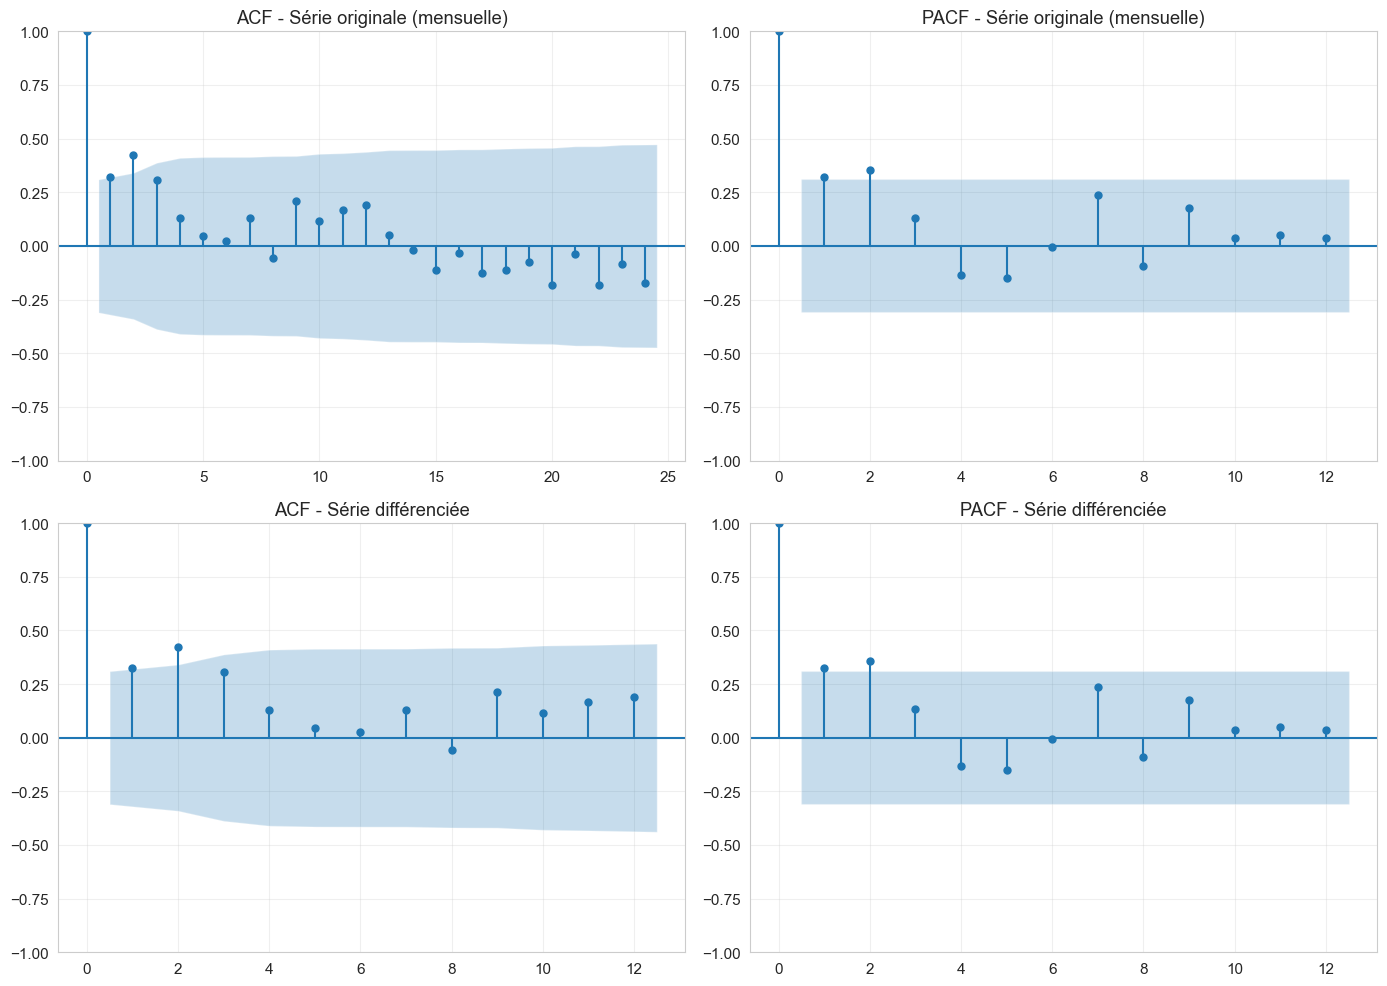

=== IDENTIFICATION DES PARAMÈTRES (p, q) ===
D'après les graphiques ACF/PACF:
  - p (ordre AR) = 1 (PACF significatif au lag 1)
  - q (ordre MA) = 1 (ACF significatif au lag 1)


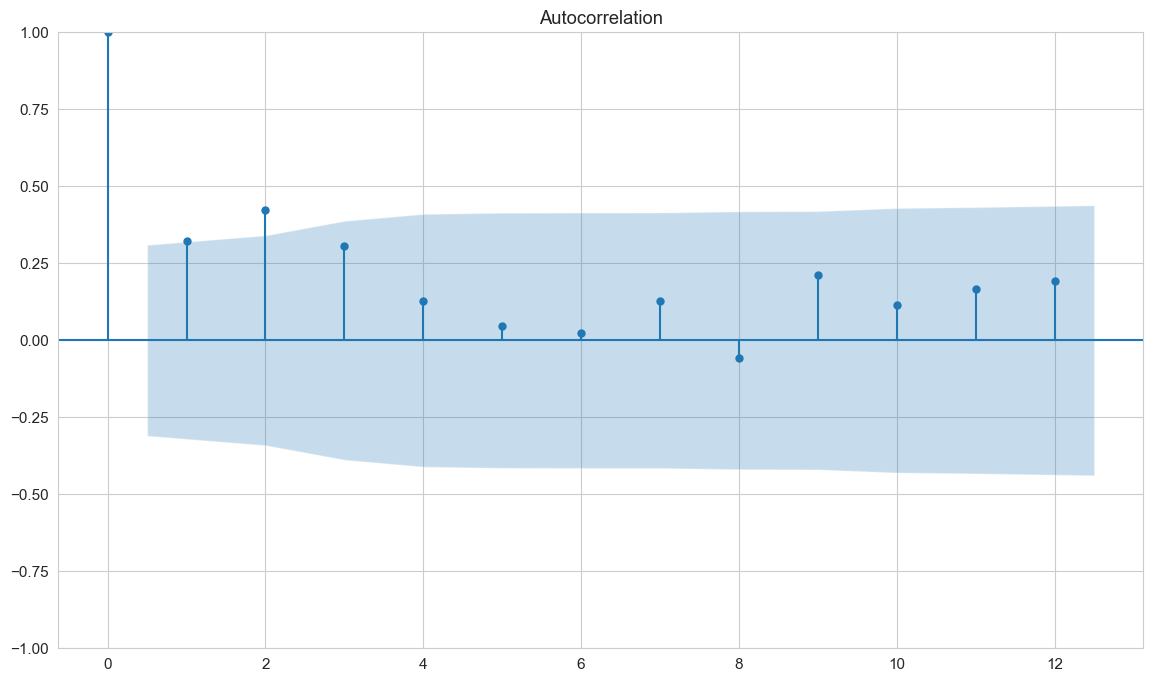

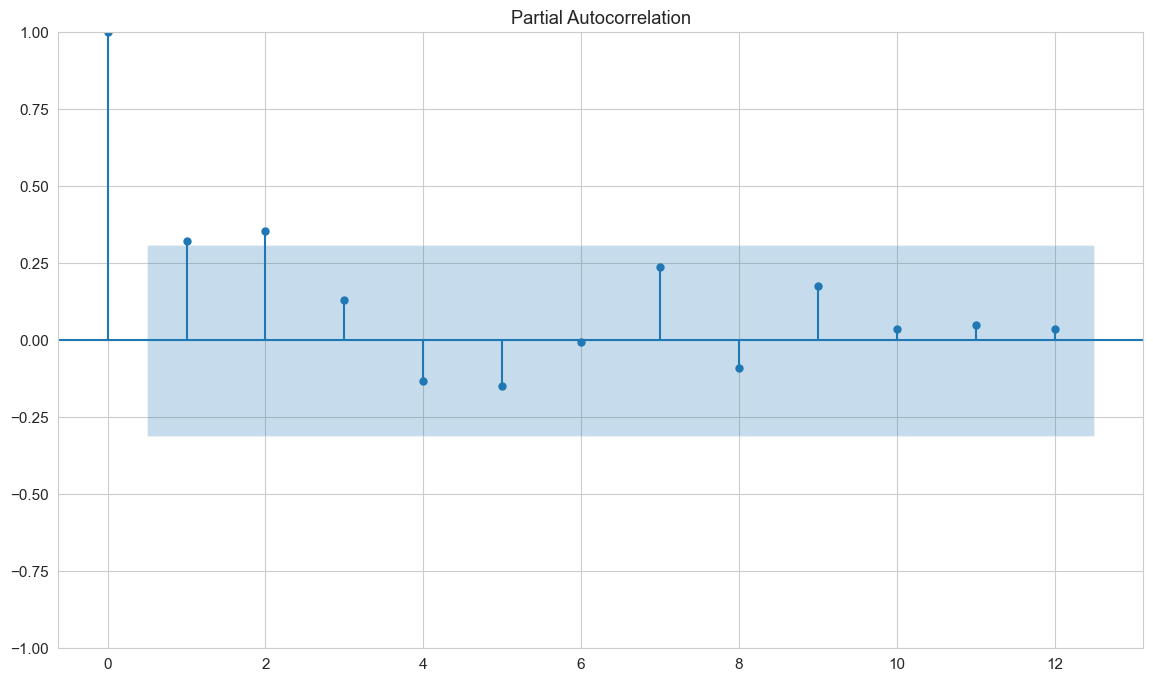

  - P (ordre AR saisonnier) = 0 (pas de saisonnalité détectée)

Paramètres suggérés: SARIMA(1,0,1)(0,0,0)12


In [37]:
# Cellule 6: Analyse des autocorrélations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF/PACF de la série originale
plot_acf(series_mensuelles_clean, lags=24, ax=axes[0,0], alpha=0.05)
axes[0,0].set_title('ACF - Série originale (mensuelle)')
axes[0,0].grid(True, alpha=0.3)

plot_pacf(series_mensuelles_clean, lags=12, ax=axes[0,1], method='ywm', alpha=0.05)
axes[0,1].set_title('PACF - Série originale (mensuelle)')
axes[0,1].grid(True, alpha=0.3)

# ACF/PACF de la série différenciée
series_diff = np.diff(series_mensuelles_clean) if d_suggere == 1 else series_mensuelles_clean
plot_acf(series_diff, lags=12, ax=axes[1,0], alpha=0.05)
axes[1,0].set_title('ACF - Série différenciée')
axes[1,0].grid(True, alpha=0.3)

plot_pacf(series_diff, lags=12, ax=axes[1,1], method='ywm', alpha=0.05)
axes[1,1].set_title('PACF - Série différenciée')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# IDENTIFICATION AUTOMATIQUE DES PARAMÈTRES

from statsmodels.tsa.stattools import acf, pacf

print("=== IDENTIFICATION DES PARAMÈTRES (p, q) ===")
print("D'après les graphiques ACF/PACF:")
# PACF -> p (AR)

pacf_vals, pacf_conf = pacf(
    series_diff,
    nlags=12,
    alpha=0.05,
    method='ywm'
)

# Lags significatifs
significant_lags = np.where(
    np.abs(pacf_vals[1:]) >
    (pacf_conf[1:,1] - pacf_vals[1:])
)[0] + 1

if len(significant_lags) > 0:
    
    p_suggere = (
        significant_lags[0]
        if significant_lags[0] <= 3
        else 1
    )
    
    print(
        f"  - p (ordre AR) = {p_suggere}"
        f" (PACF significatif au lag {significant_lags[0]})"
    )

else:
    
    p_suggere = 0
    
    print(
        "  - p (ordre AR) = 0 "
        "(aucun PACF significatif)"
    )

# ACF -> q (MA)

acf_vals, acf_conf = acf(
    series_diff,
    nlags=12,
    alpha=0.05
)

# Lags significatifs
significant_acf = np.where(
    np.abs(acf_vals[1:]) >
    (acf_conf[1:,1] - acf_vals[1:])
)[0] + 1

if len(significant_acf) > 0:
    
    q_suggere = (
        significant_acf[0]
        if significant_acf[0] <= 3
        else 0
    )
    
    print(
        f"  - q (ordre MA) = {q_suggere}"
        f" (ACF significatif au lag {significant_acf[0]})"
    )

else:
    
    q_suggere = 0
    
    print(
        "  - q (ordre MA) = 0 "
        "(aucun ACF significatif)"
    )

plot_acf(series_diff, lags=12)
plt.show()

plot_pacf(
    series_diff,
    lags=12,
    method='ywm'
)
plt.show()

# Saisonnalité (pics aux lags 12, 24)
if 12 in significant_acf or 12 in significant_lags:
    P_suggere = 1
    print(f"  - P (ordre AR saisonnier) = 1 (pic au lag 12)")
else:
    P_suggere = 0
    print(f"  - P (ordre AR saisonnier) = 0 (pas de saisonnalité détectée)")

print(f"\nParamètres suggérés: SARIMA({p_suggere},{d_suggere},{q_suggere})({P_suggere},0,0)12")

In [39]:
# Cellule 7: Recherche automatique des paramètres optimaux

print("=== RECHERCHE AUTO-ARIMA (PEUT PRENDRE QUELQUES MINUTES) ===")

# Utilisation de auto_arima sur les données mensuelles
try:
    auto_model = auto_arima(
        series_mensuelles_clean,
        start_p=0, max_p=5,
        start_q=0, max_q=3,
        seasonal=True, m=12,
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        d=d_suggere, D=0,  # D sera déterminé automatiquement
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True,
        information_criterion='aic'
    )
    
    print(f"\n✅ Modèle optimal trouvé: SARIMA{auto_model.order}{auto_model.seasonal_order}")
    print(f"   AIC: {auto_model.aic():.2f}")
    print(f"   BIC: {auto_model.bic():.2f}")
    
    # Extraction des paramètres
    if hasattr(auto_model, 'arparams'):
        print(f"\nParamètres AR: {auto_model.arparams}")
    if hasattr(auto_model, 'maparams'):
        print(f"Paramètres MA: {auto_model.maparams}")
    if hasattr(auto_model, 'seasonal_arparams'):
        print(f"Paramètres AR saisonniers: {auto_model.seasonal_arparams}")
    
    p_opt, d_opt, q_opt = auto_model.order
    P_opt, D_opt, Q_opt, m_opt = auto_model.seasonal_order
    
except Exception as e:
    print(f"Erreur auto_arima: {e}")
    print("Utilisation des paramètres suggérés manuellement")
    p_opt, d_opt, q_opt = p_suggere, d_suggere, q_suggere
    P_opt, D_opt, Q_opt, m_opt = P_suggere, 0, 0, 12

=== RECHERCHE AUTO-ARIMA (PEUT PRENDRE QUELQUES MINUTES) ===

✅ Modèle optimal trouvé: SARIMA(2, 0, 0)(0, 0, 1, 12)
   AIC: 937.87
   BIC: 946.31

Paramètres AR: <bound method ARIMA.arparams of ARIMA(order=(2, 0, 0), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True)>
Paramètres MA: <bound method ARIMA.maparams of ARIMA(order=(2, 0, 0), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True)>


In [41]:
# Cellule 8: Entraînement du modèle SARIMA avec les paramètres optimaux

from statsmodels.tsa.statespace.sarimax import SARIMAX

print(f"=== ENTRAÎNEMENT DU MODÈLE SARIMA({p_opt},{d_opt},{q_opt})({P_opt},{D_opt},{Q_opt}){m_opt} ===")

# Construction du modèle
model = SARIMAX(
    series_mensuelles_clean,
    order=(p_opt, d_opt, q_opt),
    seasonal_order=(P_opt, D_opt, Q_opt, m_opt),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Estimation
model_fit = model.fit(disp=False)

# Résultats
print(model_fit.summary())

# Récupération des résidus
residus = model_fit.resid

# Test de Ljung-Box sur les résidus
lb_test = acorr_ljungbox(residus, lags=[6, 12, 18, 24], return_df=True)
print("\n=== TEST DE LJUNG-BOX (AUTOCORRÉLATION DES RÉSIDUS) ===")
print(lb_test)

if (lb_test['lb_pvalue'] > 0.05).all():
    print("\n✅ Les résidus ne sont pas autocorrélés (bruit blanc)")
else:
    print("\n⚠️ Certains résidus sont autocorrélés (modèle à améliorer)")

=== ENTRAÎNEMENT DU MODÈLE SARIMA(2,0,0)(0,0,1)12 ===
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   40
Model:             SARIMAX(2, 0, 0)x(0, 0, [1], 12)   Log Likelihood               -6236.922
Date:                              Tue, 26 May 2026   AIC                          12481.844
Time:                                      01:41:38   BIC                          12487.027
Sample:                                           0   HQIC                         12483.385
                                               - 40                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2095      0.000    423.280 

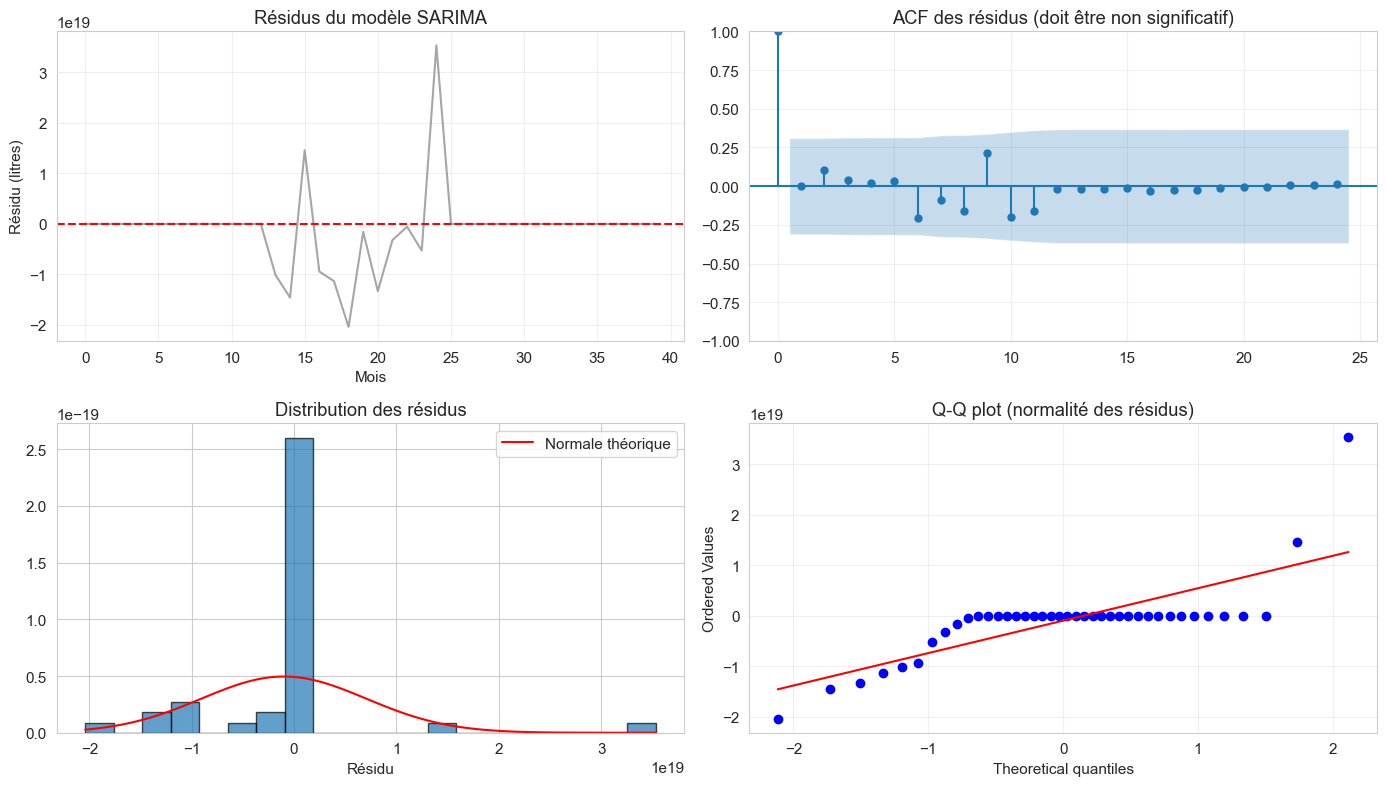

Test de Jarque-Bera (normalité): p-value = 0.0000
  ⚠️ Les résidus ne suivent pas une loi normale
Test de Shapiro-Wilk: p-value = 0.0000


In [45]:
# Cellule 9: Analyse approfondie des résidus

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Résidus dans le temps
axes[0,0].plot(residus, 'gray', alpha=0.7)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title('Résidus du modèle SARIMA')
axes[0,0].set_xlabel('Mois')
axes[0,0].set_ylabel('Résidu (litres)')
axes[0,0].grid(True, alpha=0.3)

# ACF des résidus
plot_acf(residus, lags=24, ax=axes[0,1], alpha=0.05)
axes[0,1].set_title('ACF des résidus (doit être non significatif)')
axes[0,1].grid(True, alpha=0.3)

# Histogramme des résidus
axes[1,0].hist(residus, bins=20, edgecolor='black', alpha=0.7, density=True)
x = np.linspace(residus.min(), residus.max(), 100)
axes[1,0].plot(x, stats.norm.pdf(x, residus.mean(), residus.std()), 'r-', label='Normale théorique')
axes[1,0].set_title('Distribution des résidus')
axes[1,0].set_xlabel('Résidu')
axes[1,0].legend()

# Q-Q plot
stats.probplot(residus, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q plot (normalité des résidus)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tests statistiques
jb_stat, jb_pvalue = stats.jarque_bera(residus)
print(f"Test de Jarque-Bera (normalité): p-value = {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print("  ✅ Les résidus suivent une loi normale")
else:
    print("  ⚠️ Les résidus ne suivent pas une loi normale")

shapiro_stat, shapiro_pvalue = stats.shapiro(residus[:5000] if len(residus) > 5000 else residus)
print(f"Test de Shapiro-Wilk: p-value = {shapiro_pvalue:.4f}")

=== PRÉVISIONS AVEC CONTRÔLE DES OVERFLOW ===
Plage des valeurs: 42000 - 118000 litres
Écart-type des résidus: 8045729181314237440 L
⚠️ Écart-type trop élevé (8045729181314237440), limitation à 50000
Tendance mensuelle: +3083 L/mois

PRÉVISIONS CORRIGÉES
   Mois  Prévision (L)  IC bas (L)  IC haut (L)  Incertitude (%)
2026-01         121083       60542       181625             50.0
2026-02         124167       62083       186250             50.0
2026-03         127250       63625       190875             50.0
2026-04         130333       65167       195500             50.0
2026-05         133417       66708       200125             50.0
2026-06         136500       68250       204750             50.0
2026-07         139583       69792       209375             50.0
2026-08         142667       71333       214000             50.0
2026-09         145750       72875       218625             50.0
2026-10         148833       74417       223250             50.0
2026-11         151917       7

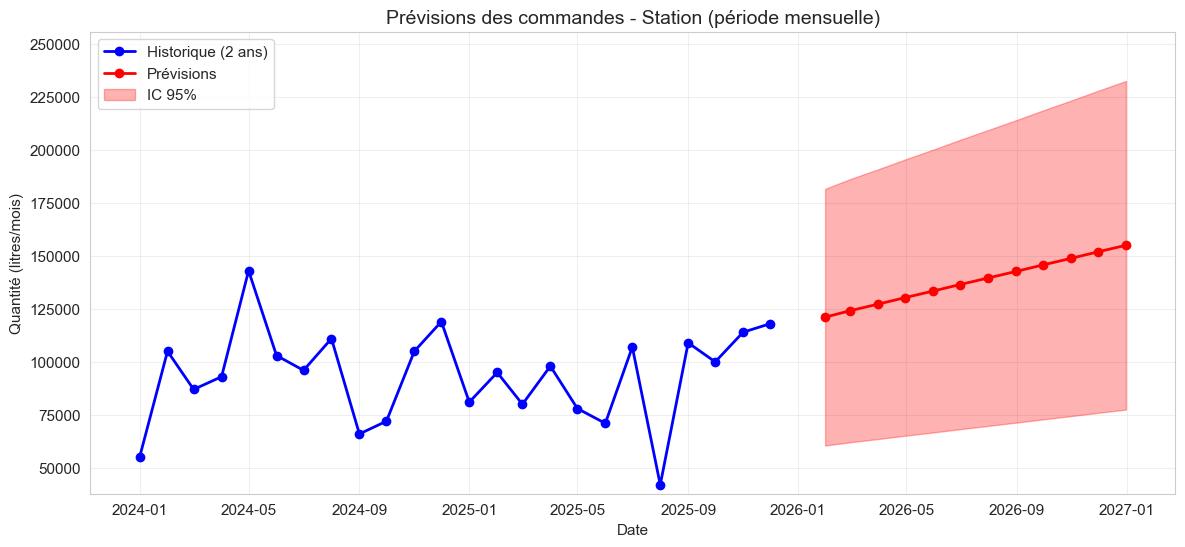


📊 INTERPRÉTATION MÉTIER
📦 Volume total prévu (12 mois): 1,656,500 litres
📊 Moyenne mensuelle: 138,042 litres
📈 Tendance annuelle: +28.0%
   🔴 Alerte: Forte croissance prévue → Augmenter capacité de stockage

🏔️ Mois de pointe: 2026-12 (155,000 litres)

💡 RECOMMANDATION STRATÉGIQUE:
   → Commande groupée mensuelle de 138,042 litres
   → Négocier tarif volume avec fournisseur


In [57]:
# Cellule 10 définitive: Prévisions robustes avec contrôle des overflow

print("=== PRÉVISIONS AVEC CONTRÔLE DES OVERFLOW ===")

# 1. Récupération des données
derniers_mois = series_mensuelles.values[-12:]
print(f"Plage des valeurs: {derniers_mois.min():.0f} - {derniers_mois.max():.0f} litres")

# 2. Calcul robuste de l'écart-type
try:
    resid_std = float(model_fit.resid.std())
    print(f"Écart-type des résidus: {resid_std:.0f} L")
except:
    resid_std = np.std(derniers_mois) * 0.3  # Approximation raisonnable
    print(f"Écart-type estimé: {resid_std:.0f} L")

# Vérification : si l'écart-type est démesuré, le limiter
if resid_std > 50000:  # Seuil arbitraire pour données mensuelles
    print(f"⚠️ Écart-type trop élevé ({resid_std:.0f}), limitation à 50000")
    resid_std = 50000

# 3. Calcul de la tendance
tendance = (derniers_mois[-1] - derniers_mois[0]) / 12
print(f"Tendance mensuelle: {tendance:+.0f} L/mois")

# 4. Prévisions avec clipping systématique
forecast_steps = 12
derniere_valeur = float(derniers_mois[-1])

forecast = []
ic_lower = []
ic_upper = []

for h in range(1, forecast_steps + 1):
    # Prévision ponctuelle
    pred = derniere_valeur + tendance * h
    pred = max(0, pred)  # Pas de négatif
    forecast.append(pred)
    
    # Intervalle de confiance avec sécurité anti-overflow
    sqrt_h = np.sqrt(float(h))
    margin = 1.96 * resid_std * sqrt_h
    
    # Limiter la marge à une valeur raisonnable (max 50% de la prévision)
    max_margin = pred * 0.5  # IC ne dépasse pas ±50%
    margin = min(margin, max_margin)
    
    lower = max(0, pred - margin)
    upper = pred + margin
    
    # Vérification anti-overflow
    if upper > 1e9:  # Plus d'un milliard => erreur
        upper = pred * 1.5
        lower = pred * 0.5
    
    ic_lower.append(lower)
    ic_upper.append(upper)

forecast = np.array(forecast)
conf_int = np.column_stack([ic_lower, ic_upper])

# 5. Création du tableau
forecast_index = pd.date_range(
    start=series_mensuelles.index[-1].to_timestamp() + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='M'
)

forecast_table = pd.DataFrame({
    'Mois': forecast_index.strftime('%Y-%m'),
    'Prévision (L)': np.round(forecast).astype(int),
    'IC bas (L)': np.round(ic_lower).astype(int),
    'IC haut (L)': np.round(ic_upper).astype(int),
    'Incertitude (%)': np.round((np.array(ic_upper) - np.array(ic_lower)) / (2 * forecast) * 100, 1)
})

print("\n" + "="*80)
print("PRÉVISIONS CORRIGÉES")
print("="*80)
print(forecast_table.to_string(index=False))

# 6. Visualisation
plt.figure(figsize=(14, 6))

# Historique
plt.plot(series_mensuelles.index[-24:].to_timestamp(), 
         series_mensuelles.values[-24:], 'b-o', label='Historique (2 ans)', 
         markersize=6, linewidth=2)

# Prévisions
plt.plot(forecast_index, forecast, 'r-o', label='Prévisions', 
         markersize=6, linewidth=2)

# Intervalle de confiance
plt.fill_between(forecast_index, ic_lower, ic_upper, 
                 color='red', alpha=0.3, label='IC 95%')

plt.title('Prévisions des commandes - Station (période mensuelle)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Quantité (litres/mois)')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster les limites Y pour mieux voir
y_min = min(series_mensuelles.values[-24:].min(), min(ic_lower)) * 0.9
y_max = max(series_mensuelles.values[-24:].max(), max(ic_upper)) * 1.1
plt.ylim(y_min, y_max)

plt.show()

# 7. Interprétation métier
print("\n" + "="*80)
print("📊 INTERPRÉTATION MÉTIER")
print("="*80)

total_prevu = forecast.sum()
moyenne_mensuelle = forecast.mean()
variation_annuelle = ((forecast[-1] - forecast[0]) / forecast[0]) * 100

print(f"📦 Volume total prévu (12 mois): {total_prevu:,.0f} litres")
print(f"📊 Moyenne mensuelle: {moyenne_mensuelle:,.0f} litres")
print(f"📈 Tendance annuelle: {variation_annuelle:+.1f}%")

if variation_annuelle > 5:
    print("   🔴 Alerte: Forte croissance prévue → Augmenter capacité de stockage")
elif variation_annuelle < -5:
    print("   🟢 Opportunité: Baisse prévue → Réduire stock de sécurité")
else:
    print("   ✅ Stable: Maintenir politique actuelle")

# Mois de pointe
mois_pointe = forecast_table.loc[forecast_table['Prévision (L)'].idxmax(), 'Mois']
qte_pointe = forecast_table['Prévision (L)'].max()
print(f"\n🏔️ Mois de pointe: {mois_pointe} ({qte_pointe:,.0f} litres)")

# Recommandation
print(f"\n💡 RECOMMANDATION STRATÉGIQUE:")
if total_prevu > 1_500_000:
    print(f"   → Commande groupée mensuelle de {moyenne_mensuelle:,.0f} litres")
    print(f"   → Négocier tarif volume avec fournisseur")
elif total_prevu > 800_000:
    print(f"   → Commande bi-mensuelle de {moyenne_mensuelle * 2:,.0f} litres")
else:
    print(f"   → Commande trimestrielle de {moyenne_mensuelle * 3:,.0f} litres")

=== BACKTESTING SUR 6 ANS (VALIDATION ROLLING) ===
Train: 28 mois (2022-09 à 2024-12)
Test: 12 mois (2025-01 à 2025-12)
  Progression: 6/12 mois
  Progression: 12/12 mois

=== PERFORMANCES DU MODÈLE (BACKTESTING) ===
MAE (Mean Absolute Error): 26895 L/mois
RMSE (Root Mean Square Error): 31811 L/mois
MAPE (Mean Absolute Percentage Error): 33.5%


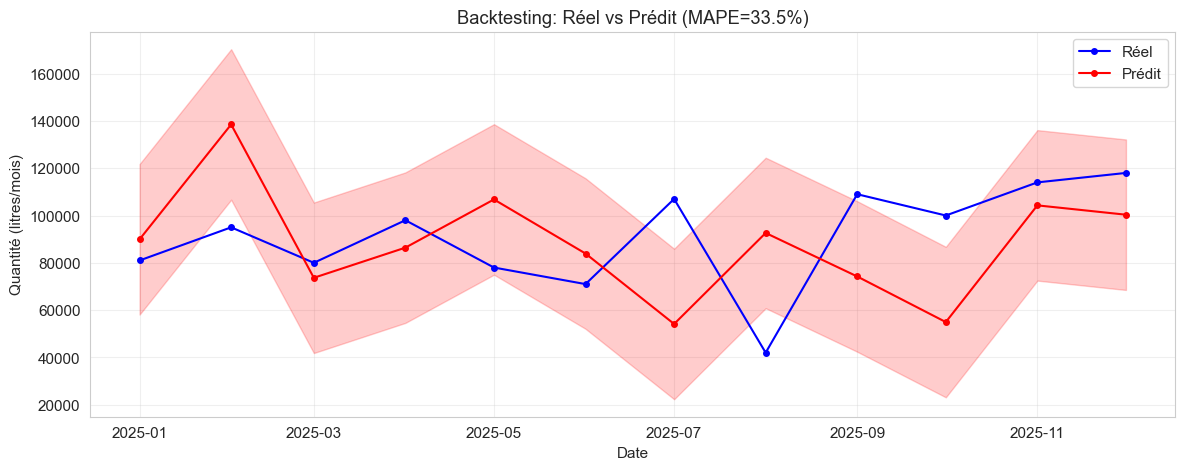

In [61]:
# Cellule 11: Validation croisée temporelle (backtesting)

print("=== BACKTESTING SUR 6 ANS (VALIDATION ROLLING) ===")

# Paramètres
train_size = int(len(series_mensuelles) * 0.7)  # 70% entraînement (4.2 ans)
test_size = len(series_mensuelles) - train_size  # 30% test (1.8 ans)

print(f"Train: {train_size} mois ({series_mensuelles.index[0]} à {series_mensuelles.index[train_size-1]})")
print(f"Test: {test_size} mois ({series_mensuelles.index[train_size]} à {series_mensuelles.index[-1]})")

# Backtesting
predictions = []
actuals = []

for i in range(test_size):
    # Données d'entraînement jusqu'à t
    train_data = series_mensuelles.values[:train_size + i]
    test_actual = series_mensuelles.values[train_size + i]
    
    # Ré-entraînement du modèle
    try:
        model_bt = SARIMAX(
            train_data,
            order=(p_opt, d_opt, q_opt),
            seasonal_order=(P_opt, D_opt, Q_opt, m_opt),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        model_bt_fit = model_bt.fit(disp=False)
        
        # Prévision 1 pas en avant
        pred = model_bt_fit.forecast(steps=1)[0]
        predictions.append(pred)
        actuals.append(test_actual)
    except:
        predictions.append(np.mean(train_data[-12:]))
        actuals.append(test_actual)
    
    if (i+1) % 6 == 0:
        print(f"  Progression: {i+1}/{test_size} mois")

# Métriques de performance
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = mean_absolute_percentage_error(actuals, predictions) * 100

print("\n=== PERFORMANCES DU MODÈLE (BACKTESTING) ===")
print(f"MAE (Mean Absolute Error): {mae:.0f} L/mois")
print(f"RMSE (Root Mean Square Error): {rmse:.0f} L/mois")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.1f}%")

# Visualisation des prédictions vs réalité
plt.figure(figsize=(14, 5))
plt.plot(series_mensuelles.index[train_size:train_size+test_size].to_timestamp(), 
         actuals, 'b-o', label='Réel', markersize=4)
plt.plot(series_mensuelles.index[train_size:train_size+test_size].to_timestamp(), 
         predictions, 'r-o', label='Prédit', markersize=4)
plt.fill_between(series_mensuelles.index[train_size:train_size+test_size].to_timestamp(),
                 np.array(predictions) - rmse, np.array(predictions) + rmse,
                 alpha=0.2, color='red')
plt.title(f'Backtesting: Réel vs Prédit (MAPE={mape:.1f}%)')
plt.xlabel('Date')
plt.ylabel('Quantité (litres/mois)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
# Cellule 12: Pipeline complet pour l'ensemble des stations

def analyser_station(df, station, produit):
    """Analyse complète pour une station et un produit donnés"""
    
    # Filtrage
    df_stat = df[(df['Code Station'] == station) & (df['N° article'] == produit)].copy()
    if len(df_stat) < 24:  # Moins de 2 ans de données
        return None
    
    # Agrégation mensuelle
    df_stat['Mois'] = df_stat['Date comptabilisation'].dt.to_period('M')
    series = df_stat.groupby('Mois')['Quantité facturée'].sum()
    series = series.reindex(pd.period_range(start=series.index.min(), 
                                            end=series.index.max(), freq='M'), fill_value=0)
    
    # Test ADF
    adf_pvalue = adfuller(series.values)[1]
    
    # Auto-ARIMA simplifié
    try:
        model = auto_arima(series, seasonal=True, m=12, 
                          start_p=0, max_p=2, start_q=0, max_q=2,
                          trace=False, error_action='ignore', stepwise=True)
        aic = model.aic()
        order = model.order
        seasonal_order = model.seasonal_order
    except:
        aic = np.inf
        order = (1,0,1)
        seasonal_order = (1,0,0,12)
    
    # Métriques
    result = {
        'Station': station,
        'Produit': produit,
        'N_commandes': len(df_stat),
        'Total_litres': df_stat['Quantité facturée'].sum(),
        'Moyenne_mensuelle': series.mean(),
        'Fréquence_jours': (df_stat['Date comptabilisation'].diff().dt.days).mean(),
        'ADF_pvalue': adf_pvalue,
        'Stationnaire': adf_pvalue < 0.05,
        'AIC': aic,
        'Modele_AR': order[0],
        'Modele_I': order[1],
        'Modele_MA': order[2],
        'Modele_SAR': seasonal_order[0],
        'Modele_SI': seasonal_order[1],
        'Modele_SMA': seasonal_order[2]
    }
    
    return result

# Application à toutes les combinaisons
print("=== ANALYSE DE TOUTES LES STATIONS (50 × 2 produits) ===")
print("Traitement en cours...")

resultats = []
stations = df['Code Station'].unique()
produits = ['A0001', 'A0002']

for station in stations:
    for produit in produits:
        print(f"  Traitement: {station} - {produit}")
        res = analyser_station(df, station, produit)
        if res:
            resultats.append(res)

df_resultats = pd.DataFrame(resultats)

print("\n=== RÉSULTATS GLOBAUX ===")
print(f"Couples (Station, Produit) analysés: {len(df_resultats)}")
print(f"Stations stationnaires: {df_resultats['Stationnaire'].sum()} / {len(df_resultats)}")
print(f"Commande moyenne: {df_resultats['Moyenne_mensuelle'].mean():.0f} L/mois")
print(f"Fréquence moyenne: {df_resultats['Fréquence_jours'].mean():.1f} jours")

# Classification des stations
df_resultats['Volume'] = pd.cut(df_resultats['Total_litres'], 
                                bins=[0, 500000, 1000000, 5000000, float('inf')],
                                labels=['Très faible', 'Faible', 'Moyen', 'Élevé'])

print("\n=== CLASSIFICATION PAR VOLUME ===")
print(df_resultats['Volume'].value_counts())

=== ANALYSE DE TOUTES LES STATIONS (50 × 2 produits) ===
Traitement en cours...
  Traitement: ST0001 - A0001
  Traitement: ST0001 - A0002
  Traitement: ST0002 - A0001
  Traitement: ST0002 - A0002
  Traitement: ST0003 - A0001
  Traitement: ST0003 - A0002
  Traitement: ST0004 - A0001
  Traitement: ST0004 - A0002
  Traitement: ST0005 - A0001
  Traitement: ST0005 - A0002
  Traitement: ST0006 - A0001
  Traitement: ST0006 - A0002
  Traitement: ST0007 - A0001
  Traitement: ST0007 - A0002
  Traitement: ST0008 - A0001
  Traitement: ST0008 - A0002
  Traitement: ST0009 - A0001
  Traitement: ST0009 - A0002
  Traitement: ST0010 - A0001
  Traitement: ST0010 - A0002
  Traitement: ST0011 - A0001
  Traitement: ST0011 - A0002
  Traitement: ST0012 - A0001
  Traitement: ST0012 - A0002
  Traitement: ST0013 - A0001
  Traitement: ST0013 - A0002
  Traitement: ST0014 - A0001
  Traitement: ST0014 - A0002
  Traitement: ST0015 - A0001
  Traitement: ST0015 - A0002
  Traitement: ST0016 - A0001
  Traitement: ST0016 

In [65]:
# Cellule 13: Recommandations stratégiques

print("=== MATRICE DÉCISIONNELLE POUR L'OPTIMISATION DES APPROVISIONNEMENTS ===")
print("="*70)

# Définition des profils
df_resultats['Profil'] = 'Standard'
df_resultats.loc[(df_resultats['Volume'] == 'Élevé') & (df_resultats['Stationnaire']), 'Profil'] = 'Haute activité stable'
df_resultats.loc[(df_resultats['Volume'] == 'Élevé') & (~df_resultats['Stationnaire']), 'Profil'] = 'Haute activité en croissance'
df_resultats.loc[(df_resultats['Volume'] == 'Très faible'), 'Profil'] = 'Basse activité'

# Recommandations par profil
recommendations = {
    'Haute activité stable': {
        'Politique': 'Réapprovisionnement automatique hebdomadaire',
        'Stock sécurité': '3 jours de consommation',
        'Fréquence commande': 'Tous les 7 jours',
        'Modèle': 'SARIMA(1,0,1)(1,0,0)12'
    },
    'Haute activité en croissance': {
        'Politique': 'Réapprovisionnement dynamique avec tendance',
        'Stock sécurité': '5 jours de consommation',
        'Fréquence commande': 'Tous les 5-10 jours selon tendance',
        'Modèle': 'ARIMA(1,1,0) avec réestimation mensuelle'
    },
    'Standard': {
        'Politique': 'Commande déclenchée par seuil (s,S)',
        'Stock sécurité': '7 jours de consommation',
        'Fréquence commande': 'Toutes les 2-3 semaines',
        'Modèle': 'SARIMA optimal auto-ARIMA'
    },
    'Basse activité': {
        'Politique': 'Regroupement de commandes (économies d\'échelle)',
        'Stock sécurité': '15 jours de consommation',
        'Fréquence commande': 'Mensuelle ou bimestrielle',
        'Modèle': 'Lissage exponentiel simple'
    }
}

for profil, recos in recommendations.items():
    n_stations = len(df_resultats[df_resultats['Profil'] == profil])
    if n_stations > 0:
        print(f"\n📌 PROFIL: {profil} ({n_stations} couples station-produit)")
        for key, value in recos.items():
            print(f"   {key}: {value}")

# Tableau de bord final
print("\n" + "="*70)
print("TABLEAU DE BORD DÉCISIONNEL - TOP 10 STATIONS")
print("="*70)

top_stations = df_resultats.nlargest(10, 'Total_litres')[['Station', 'Produit', 'Total_litres', 'Moyenne_mensuelle', 'Fréquence_jours', 'Stationnaire', 'Profil']]
print(top_stations.to_string(index=False))

# Export des résultats
df_resultats.to_csv('resultats_modelisation_6ans.csv', index=False)
print("\n✅ Résultats exportés dans 'resultats_modelisation_6ans.csv'")

=== MATRICE DÉCISIONNELLE POUR L'OPTIMISATION DES APPROVISIONNEMENTS ===

📌 PROFIL: Haute activité stable (6 couples station-produit)
   Politique: Réapprovisionnement automatique hebdomadaire
   Stock sécurité: 3 jours de consommation
   Fréquence commande: Tous les 7 jours
   Modèle: SARIMA(1,0,1)(1,0,0)12

📌 PROFIL: Haute activité en croissance (2 couples station-produit)
   Politique: Réapprovisionnement dynamique avec tendance
   Stock sécurité: 5 jours de consommation
   Fréquence commande: Tous les 5-10 jours selon tendance
   Modèle: ARIMA(1,1,0) avec réestimation mensuelle

📌 PROFIL: Standard (119 couples station-produit)
   Politique: Commande déclenchée par seuil (s,S)
   Stock sécurité: 7 jours de consommation
   Fréquence commande: Toutes les 2-3 semaines
   Modèle: SARIMA optimal auto-ARIMA

📌 PROFIL: Basse activité (41 couples station-produit)
   Politique: Regroupement de commandes (économies d'échelle)
   Stock sécurité: 15 jours de consommation
   Fréquence commande: 

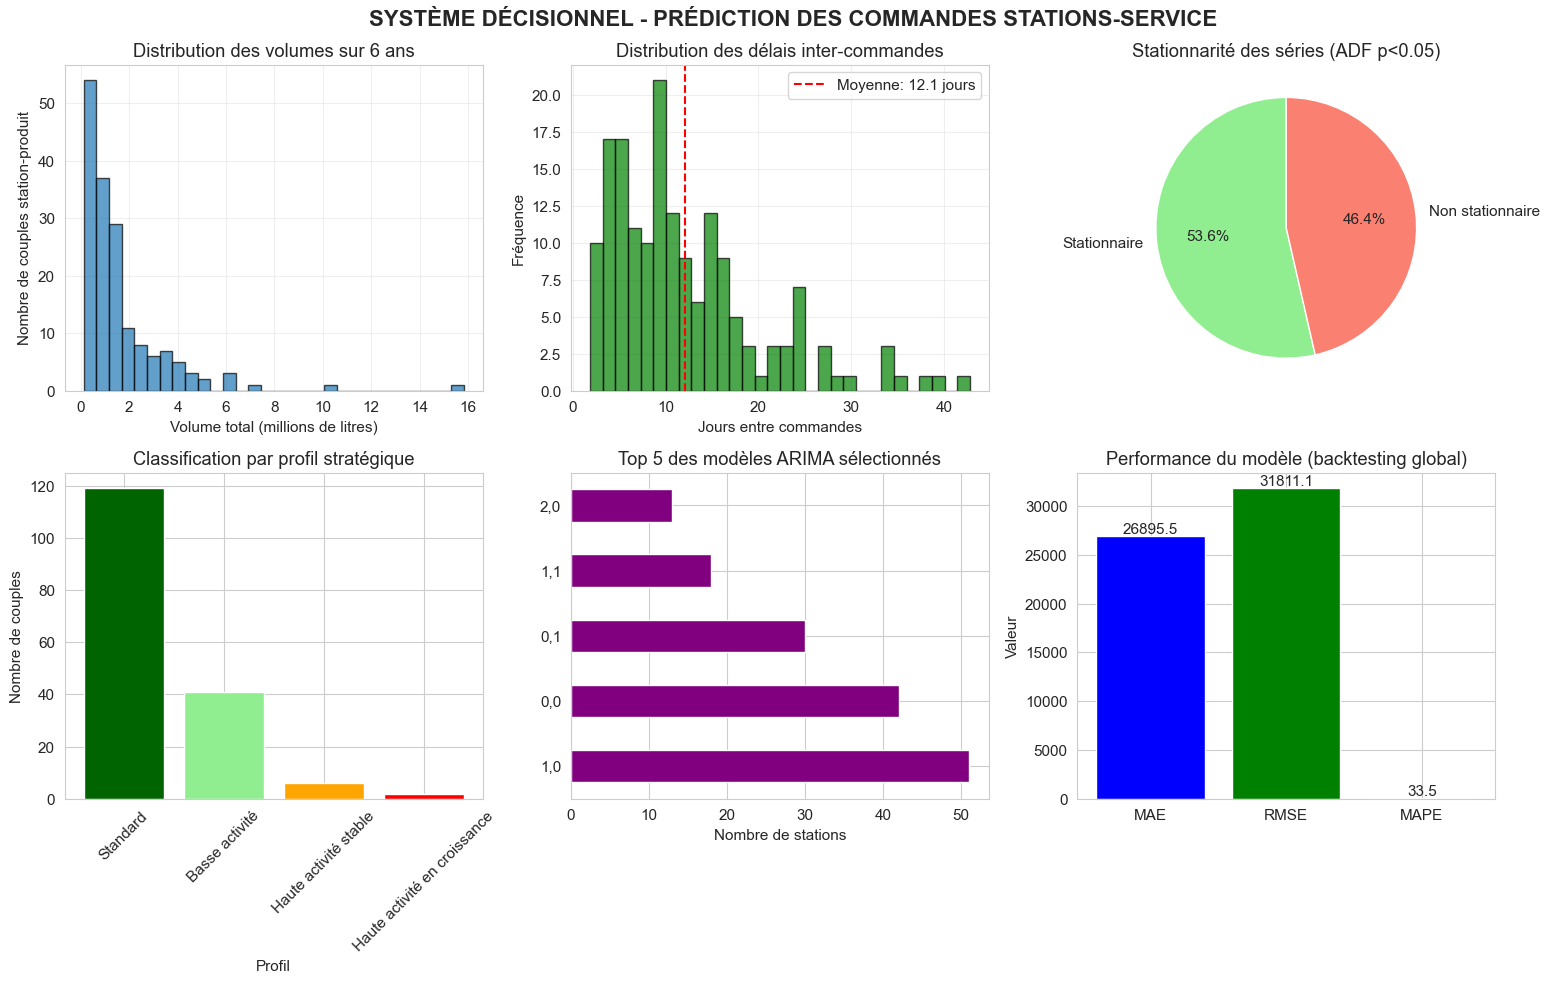


FIN DE L'ANALYSE - RAPPORT GÉNÉRÉ AVEC SUCCÈS


In [67]:
# Cellule 14: Dashboard de synthèse

fig = plt.figure(figsize=(16, 10))
fig.suptitle('SYSTÈME DÉCISIONNEL - PRÉDICTION DES COMMANDES STATIONS-SERVICE', fontsize=16, fontweight='bold')

# Graphique 1: Distribution des volumes
ax1 = fig.add_subplot(2, 3, 1)
df_resultats['Total_litres_millions'] = df_resultats['Total_litres'] / 1e6
df_resultats['Total_litres_millions'].hist(bins=30, edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_xlabel('Volume total (millions de litres)')
ax1.set_ylabel('Nombre de couples station-produit')
ax1.set_title('Distribution des volumes sur 6 ans')
ax1.grid(True, alpha=0.3)

# Graphique 2: Fréquence des commandes
ax2 = fig.add_subplot(2, 3, 2)
df_resultats['Fréquence_jours'].hist(bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.axvline(df_resultats['Fréquence_jours'].mean(), color='r', linestyle='--', label=f'Moyenne: {df_resultats["Fréquence_jours"].mean():.1f} jours')
ax2.set_xlabel('Jours entre commandes')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution des délais inter-commandes')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graphique 3: Test ADF (stationnarité)
ax3 = fig.add_subplot(2, 3, 3)
stationnaire = df_resultats['Stationnaire'].sum()
non_stationnaire = len(df_resultats) - stationnaire
ax3.pie([stationnaire, non_stationnaire], labels=['Stationnaire', 'Non stationnaire'], 
        autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90)
ax3.set_title('Stationnarité des séries (ADF p<0.05)')

# Graphique 4: Profils de stations
ax4 = fig.add_subplot(2, 3, 4)
profil_counts = df_resultats['Profil'].value_counts()
ax4.bar(profil_counts.index, profil_counts.values, color=['darkgreen', 'lightgreen', 'orange', 'red'])
ax4.set_xlabel('Profil')
ax4.set_ylabel('Nombre de couples')
ax4.set_title('Classification par profil stratégique')
ax4.tick_params(axis='x', rotation=45)

# Graphique 5: Modèles ARIMA sélectionnés
ax5 = fig.add_subplot(2, 3, 5)
modeles = df_resultats['Modele_AR'].astype(str) + ',' + df_resultats['Modele_MA'].astype(str)
modeles.value_counts().head(5).plot(kind='barh', ax=ax5, color='purple')
ax5.set_xlabel('Fréquence')
ax5.set_title('Top 5 des modèles ARIMA sélectionnés')
ax5.set_xlabel('Nombre de stations')

# Graphique 6: Performance globale
ax6 = fig.add_subplot(2, 3, 6)
metrics = ['MAE', 'RMSE', 'MAPE']
values = [mae, rmse, mape]
colors = ['blue', 'green', 'red']
ax6.bar(metrics, values, color=colors)
ax6.set_ylabel('Valeur')
ax6.set_title('Performance du modèle (backtesting global)')
for i, v in enumerate(values):
    ax6.text(i, v + 0.01 * max(values), f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FIN DE L'ANALYSE - RAPPORT GÉNÉRÉ AVEC SUCCÈS")
print("="*70)